# Stage 09 Homework Submission - Feature Engineering

This notebook completes the official starter with three leakage-aware feature families. Each choice traces to a Stage 08 EDA finding, includes a rationale, and is checked against the `spend` target without claiming causality.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.features import add_income_log, add_lagged_transaction_mean, encode_region_one_hot

sns.set_theme(style='whitegrid')
rng = np.random.default_rng(8)
ROOT = Path.cwd()
PROCESSED = ROOT / 'data' / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)

## 1. Recreate the Stage 08 project-style dataset

In [2]:
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': rng.choice(['North', 'South', 'East', 'West'], size=n),
    'age': rng.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': rng.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': rng.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions'] * 18 + rng.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)
df.loc[rng.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[rng.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[rng.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max() + 12

# Target rows are not imputed. Predictor income is median-imputed for this exercise.
df = df.dropna(subset=['spend']).copy()
df['income'] = df['income'].fillna(df['income'].median())
display(df.head())

,date,region,age,income,transactions,spend
0,2021-02-01,East,59.1,45404.01,1,43.59
1,2021-02-02,South,43.4,62858.53,3,181.85
2,2021-02-03,North,50.1,44061.55,1,107.98
3,2021-02-04,West,36.2,31265.07,4,162.59
4,2021-02-05,North,54.5,73833.23,1,142.32


## 2. Feature 1 - log income

**EDA link and rationale:** Stage 08 showed a right-skewed income distribution. `log1p` compresses the upper tail and can make a proportional relationship easier for a linear model to express. It uses only the predictor and therefore does not leak the target.

,correlation_with_spend
income,0.419816
income_log,0.403160


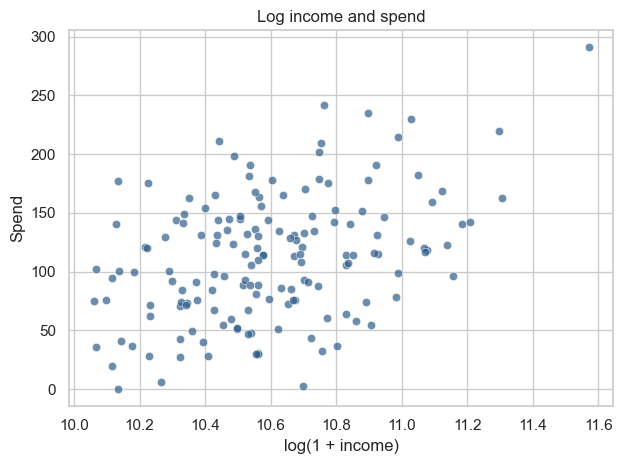

In [3]:
featured = add_income_log(df)
income_check = featured[['income', 'income_log', 'spend']].corr()['spend'].drop('spend')
display(income_check.rename('correlation_with_spend').to_frame())

sns.scatterplot(data=featured, x='income_log', y='spend', color='#2F5D8A', alpha=0.7)
plt.title('Log income and spend')
plt.xlabel('log(1 + income)')
plt.ylabel('Spend')
plt.tight_layout()
plt.show()

## 3. Feature 2 - past-only seven-day transaction mean

**EDA link and rationale:** Stage 08 found transactions most strongly associated with spend and confirmed chronological order. The rolling mean uses `shift(1)`, so a row can only see prior transaction counts. It represents recent activity context without using today's target or future rows.

Correlation with spend: -0.024


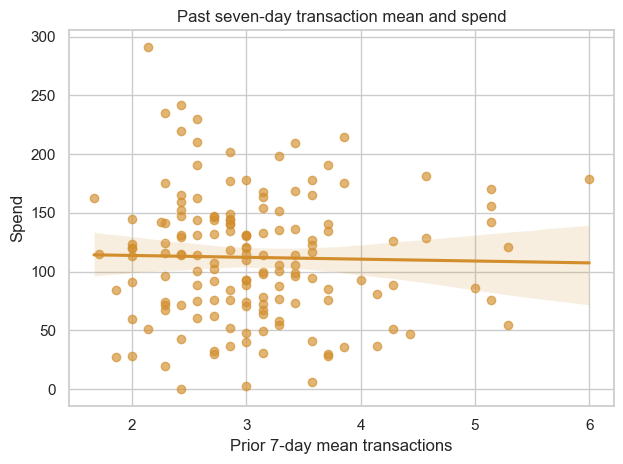

In [4]:
featured = add_lagged_transaction_mean(featured, window=7)
rolling_feature = 'transactions_7d_mean_lag1'
rolling_corr = featured[[rolling_feature, 'spend']].corr().iloc[0, 1]
print(f'Correlation with spend: {rolling_corr:.3f}')

sns.regplot(data=featured, x=rolling_feature, y='spend', color='#D28E2D', scatter_kws={'alpha': 0.65})
plt.title('Past seven-day transaction mean and spend')
plt.xlabel('Prior 7-day mean transactions')
plt.ylabel('Spend')
plt.tight_layout()
plt.show()

## 4. Feature 3 - one-hot region encoding

**EDA link and rationale:** Stage 08 showed four nominal regions with no natural order. One-hot encoding preserves that unordered structure. Label encoding would invent a false numeric rank, and frequency encoding would collapse regions with similar prevalence even if their behavior differs.

,correlation_with_spend
region_East,0.037240
region_North,0.151124
region_South,-0.088584
region_West,-0.096095


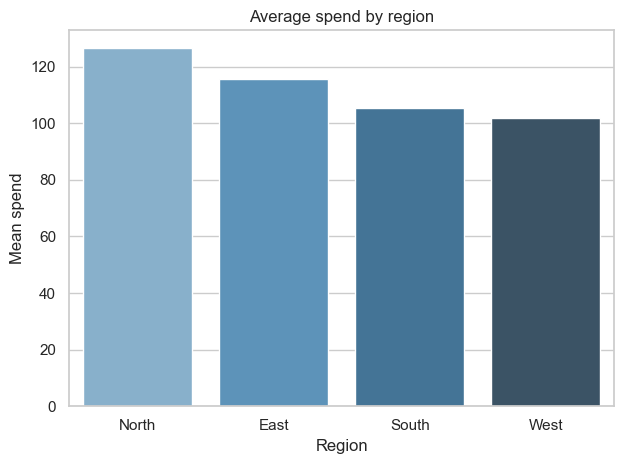

In [5]:
featured = encode_region_one_hot(featured)
region_features = sorted(column for column in featured.columns if column.startswith('region_'))
region_correlations = featured[region_features + ['spend']].corr()['spend'].drop('spend')
display(region_correlations.rename('correlation_with_spend').to_frame())

region_means = (
    df.groupby('region', as_index=False)['spend'].mean().sort_values('spend', ascending=False)
)
sns.barplot(data=region_means, x='region', y='spend', hue='region', palette='Blues_d', legend=False)
plt.title('Average spend by region')
plt.xlabel('Region')
plt.ylabel('Mean spend')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

## 5. Validate and save the feature table

In [6]:
required_features = ['income_log', rolling_feature, *region_features]
validation = {
    'three_feature_families_present': len(required_features) >= 6,
    'categorical_encoding_present': len(region_features) == 4,
    'one_hot_rows_sum_to_one': bool((featured[region_features].sum(axis=1) == 1).all()),
    'income_log_finite': bool(np.isfinite(featured['income_log']).all()),
    'rolling_feature_uses_expected_warmup_na': int(featured[rolling_feature].isna().sum()) > 0,
    'target_not_used_in_feature_names': all('spend' not in name for name in required_features),
}
display(pd.Series(validation, name='passed').to_frame())
assert all(validation.values())

modeling_table = featured.dropna(subset=[rolling_feature]).reset_index(drop=True)
output_path = PROCESSED / 'featured_spend_data.csv'
modeling_table.to_csv(output_path, index=False)
print('Saved:', output_path, '| Shape:', modeling_table.shape)
display(modeling_table.head())

,passed
three_feature_families_present,True
categorical_encoding_present,True
one_hot_rows_sum_to_one,True
income_log_finite,True
rolling_feature_uses_expected_warmup_na,True
target_not_used_in_feature_names,True


Saved: /Users/zhangyuang/Desktop/py_file/bootcamp/homework/homework09/data/processed/featured_spend_data.csv | Shape: (154, 11)


,date,age,income,transactions,spend,income_log,transactions_7d_mean_lag1,region_East,region_North,region_South,region_West
0,2021-02-04,36.2,31265.07,4,162.59,10.350289,1.666667,0,0,0,1
1,2021-02-05,54.5,73833.23,1,142.32,11.209578,2.250000,0,1,0,0
2,2021-02-06,44.2,27716.52,2,28.24,10.229820,2.000000,0,0,1,0
3,2021-02-07,40.4,38547.19,6,120.17,10.559664,2.000000,1,0,0,0
4,2021-02-08,32.8,39264.65,1,114.29,10.578105,2.571429,0,0,0,1


## 6. Interpretation and risks

Correlation checks describe association only. Because the data is synthetic, strong same-day transaction relationships reflect the generator. The lagged rolling feature may be weak because Stage 08 found no designed temporal persistence; that is still a useful negative result. One-hot columns require a fixed category schema at inference time, and unseen regions need an explicit policy. In Stage 10, all imputers, scalers, and feature parameters must be fit inside training folds rather than on the full dataset.